In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_excel(r"C:\Users\ankus\Desktop\Telco_customer_churn.xlsx")
df.shape

(7043, 33)

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [7]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [8]:
df['Total Charges'].dtype

dtype('float64')

In [9]:
print("Nulls after conversion:\n", df.isnull().sum()[df.isnull().sum() > 0])

Nulls after conversion:
 Total Charges      11
Churn Reason     5174
dtype: int64


In [10]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [11]:
df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

In [12]:
print("\nChurn rate:", df['Churn Label'].mean().round(4),f"{df['Churn Label'].mean()*100:.1f}%")


Churn rate: 0.2654 26.5%


In [13]:
print("Class counts:\n", df['Churn Label'].value_counts())

Class counts:
 Churn Label
0    5174
1    1869
Name: count, dtype: int64


In [14]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [15]:
cat_cols

['CustomerID',
 'Country',
 'State',
 'City',
 'Lat Long',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Churn Reason']

In [16]:
cat_cols.remove('CustomerID')

In [17]:
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")


Country: ['United States']

State: ['California']

City: ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']

Lat Long: ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']

Gender: ['Male' 'Female']

Senior Citizen: ['No' 'Yes']

Partner: ['No' 'Yes']

Dependents: ['No' 'Yes']

Phone Service: ['Yes' 'No']

Multiple Lines: ['No' 'Yes' 'No phone service']

Internet Service: ['DSL' 'Fiber optic' 'No']

Online Security: ['Yes' 'No' 'No internet service']

Online Backup: ['Yes' 'No' 'No internet service']

Device Protection: ['No' 'Yes' 'No internet service']

Tech Support: ['No' 'Yes' 'No internet service']

Streaming TV: ['No' 'Yes' 'No internet service']

Streaming Movies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'Two year' 'One year']

Paperless Billing: ['Yes' 'No']

Payment Method: ['Mailed check' 'Electronic check' 

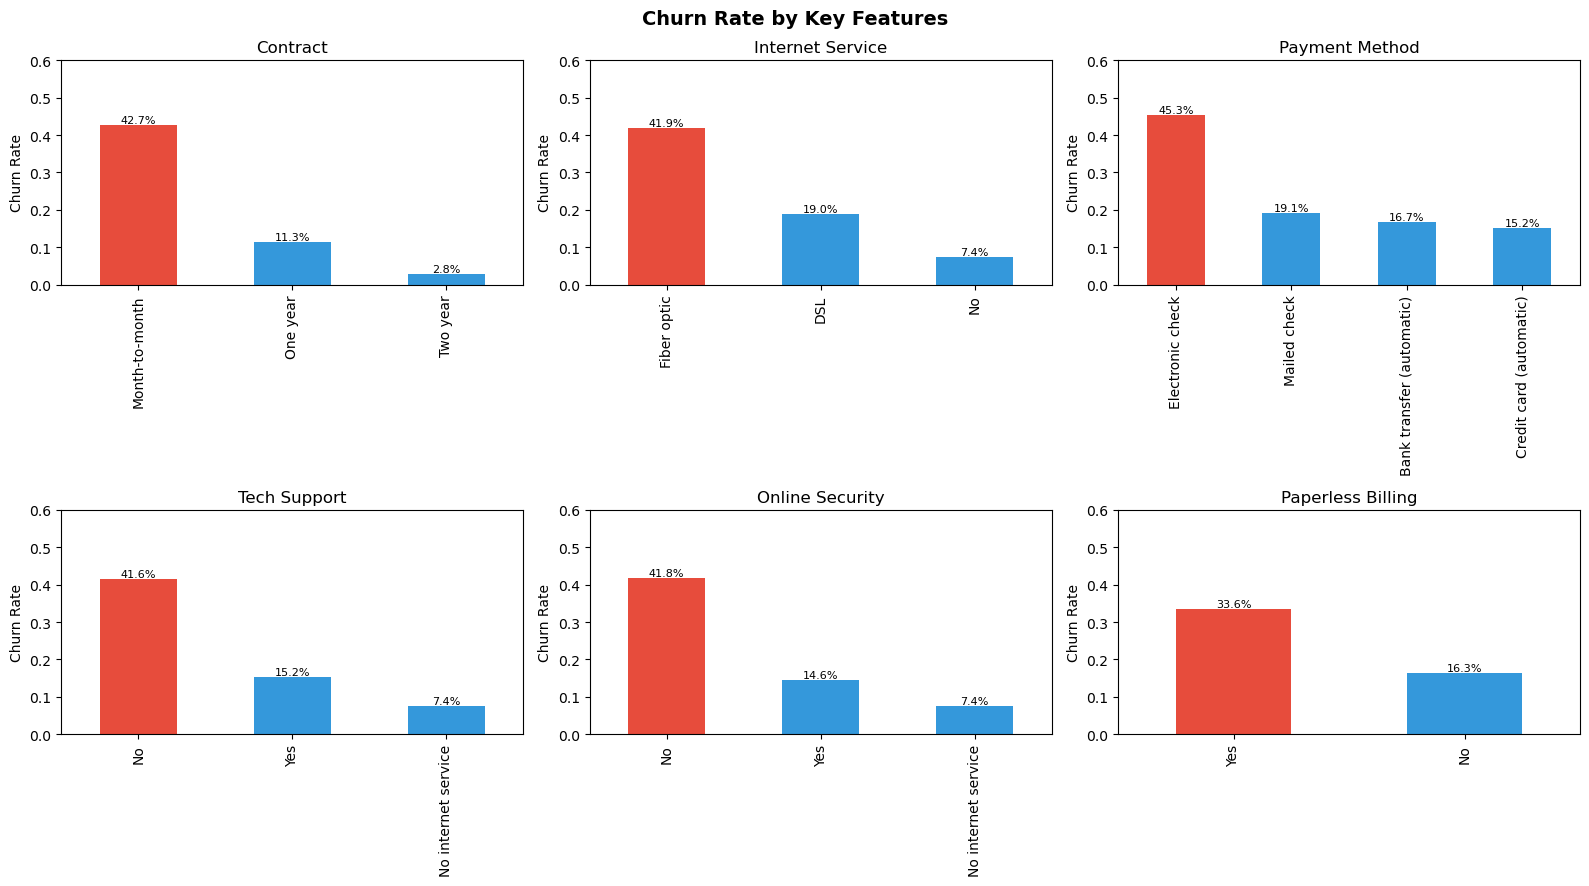

In [22]:
#CHURN RATE BY KEY FEAUTURES
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Churn Rate by Key Features', fontsize=14, fontweight='bold')

key_cats = ['Contract', 'Internet Service', 'Payment Method',
            'Tech Support', 'Online Security', 'Paperless Billing']
for ax, col in zip(axes.flatten(), key_cats):
    churn_by_col = df.groupby(col)['Churn Label'].mean().sort_values(ascending=False)
    churn_by_col.plot(kind='bar', ax=ax, color=['#e74c3c' if x > 0.26 else '#3498db' for x in churn_by_col.values])
    ax.set_title(col)
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.set_ylim(0, 0.6)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', 
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('churn_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)
print(f"Total records       : {len(df):,}")
print(f"Features available  : {df.shape[1]-2} (excl. ID + target)")
print(f"Missing values      : 0 (fixed)")
print(f"Churn rate          : {df['Churn Label'].mean():.1%}")
print(f"Avg Monthly Charges : ${df['Monthly Charges'].mean():.2f}")
print(f"Avg Tenure          : {df['Tenure Months'].mean():.1f} months")
print(f"Churner avg tenure  : {df[df['Churn Label']==1]['Tenure Months'].mean():.1f} months")
print(f"Non-churner avg     : {df[df['Churn Label']==0]['Tenure Months'].mean():.1f} months")

# Save cleaned data for next phase
df.to_csv('telco_cleaned.csv', index=False)
print("\n Saved: telco_cleaned.csv")

DATA QUALITY SUMMARY
Total records       : 7,043
Features available  : 31 (excl. ID + target)
Missing values      : 0 (fixed)
Churn rate          : 26.5%
Avg Monthly Charges : $64.76
Avg Tenure          : 32.4 months
Churner avg tenure  : 18.0 months
Non-churner avg     : 37.6 months

 Saved: telco_cleaned.csv


In [29]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [30]:
#PHASE 2 Feauture Engineering

In [31]:
df = pd.read_csv('telco_cleaned.csv')

In [32]:
df.columns = (df.columns
                .str.strip()
                .str.lower()
                .str.replace(' ', '_'))


In [33]:
df.columns

Index(['customerid', 'count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_label', 'churn_value',
       'churn_score', 'cltv', 'churn_reason'],
      dtype='object')

In [37]:
print("\nCLTV range     :", df['cltv'].min(),'-', df['cltv'].max())
print("Churn Score range:", df['churn_score'].min(),'-', df['churn_score'].max())
print("Churn reasons (top 10):\n", 
      df[df['churn_label']==1]['churn_reason'].value_counts().head(10))


CLTV range     : 2003 - 6500
Churn Score range: 5 - 100
Churn reasons (top 10):
 churn_reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64


In [38]:
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce').fillna(0)
df['churn_value']   = df['churn_value'].astype(int)

In [39]:
yes_no_cols = ['partner', 'dependents', 'phone_service', 'paperless_billing',
               'multiple_lines', 'online_security', 'online_backup',
               'device_protection', 'tech_support', 'streaming_tv', 
               'streaming_movies']

In [40]:
for col in yes_no_cols:
    # Collapse "No internet service" / "No phone service" - "No"
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service':    'No'
    })
    df[col] = (df[col] == 'Yes').astype(int)

In [42]:
df[['online_security','tech_support','streaming_tv']].head(3)

,online_security,tech_support,streaming_tv
0,1,0,0
1,0,0,0
2,0,0,1


In [43]:
# ── 3. CLTV-BASED VALUE TIER SEGMENTATION ────────────────────
# This is the core business segmentation — HIGH / MID / LOW value customers
# We use CLTV (already calculated in the dataset) + pd.qcut for equal-sized tiers

df['value_tier'] = pd.qcut(
    df['cltv'],
    q=3,
    labels=['Low Value', 'Mid Value', 'High Value']
)

In [44]:
print("\nValue Tier distribution:\n", df['value_tier'].value_counts())
print("\nCLTV ranges per tier:\n", 
      df.groupby('value_tier')['cltv'].agg(['min','max','mean']).round(0))



Value Tier distribution:
 value_tier
Mid Value     2349
Low Value     2348
High Value    2346
Name: count, dtype: int64

CLTV ranges per tier:
              min   max    mean
value_tier                    
Low Value   2003  3975  2987.0
Mid Value   3976  5101  4540.0
High Value  5102  6500  5675.0


In [45]:
#Churn Rate Per tier

In [46]:
tier_churn = df.groupby('value_tier').agg(
    total_customers=('churn_value', 'count'),
    churners=('churn_value', 'sum'),
    churn_rate=('churn_value', 'mean'),
    avg_monthly_charges=('monthly_charges', 'mean'),
    avg_cltv=('cltv', 'mean')
).round(2)
tier_churn['revenue_at_risk'] = (
    tier_churn['churners'] * tier_churn['avg_monthly_charges']
).round(0)

print("\n=== BUSINESS SUMMARY: CHURN BY VALUE TIER ===")
print(tier_churn.to_string())


=== BUSINESS SUMMARY: CHURN BY VALUE TIER ===
            total_customers  churners  churn_rate  avg_monthly_charges  avg_cltv  revenue_at_risk
value_tier                                                                                       
Low Value              2348       807        0.34                60.68   2987.26          48969.0
Mid Value              2349       563        0.24                66.08   4539.62          37203.0
High Value             2346       499        0.21                67.53   5675.03          33697.0


In [47]:
# ── 4. TENURE BUCKETING ──────────────────────────────────────
# Lifecycle stage matters more than raw tenure number
df['tenure_band'] = pd.cut(
    df['tenure_months'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49+ mo']
)

# Churn rate by lifecycle stage
print("\nChurn rate by tenure band:\n",
      df.groupby('tenure_band')['churn_value'].mean().round(3))


Churn rate by tenure band:
 tenure_band
0-6 mo      0.533
7-12 mo     0.359
13-24 mo    0.287
25-48 mo    0.204
49+ mo      0.095
Name: churn_value, dtype: float64


In [48]:
# ── 5. SERVICE BUNDLE SCORE ──────────────────────────────────
# How many value-added services does each customer use?
# Hypothesis: more bundled = more sticky = less likely to churn

service_cols = ['online_security', 'online_backup', 'device_protection',
                'tech_support', 'streaming_tv', 'streaming_movies']

df['service_bundle_score'] = df[service_cols].sum(axis=1)
# Score: 0 (no add-ons) → 6 (fully bundled)

print("\nBundle score distribution:\n", 
      df['service_bundle_score'].value_counts().sort_index())
print("\nChurn rate by bundle score:\n",
      df.groupby('service_bundle_score')['churn_value'].mean().round(3))


Bundle score distribution:
 service_bundle_score
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

Churn rate by bundle score:
 service_bundle_score
0    0.214
1    0.458
2    0.358
3    0.274
4    0.223
5    0.124
6    0.053
Name: churn_value, dtype: float64


In [49]:
# ── 6. ARPU PROXY & HIGH CHARGE FLAG ─────────────────────────
# ARPU = Average Revenue Per User (Monthly Charges here is effectively ARPU)
# Flag customers paying above median — they're highest revenue priority

median_charge = df['monthly_charges'].median()
df['high_arpu'] = (df['monthly_charges'] > median_charge).astype(int)

# Risk score: high charges + short tenure = most vulnerable
df['risk_flag'] = (
    (df['monthly_charges'] > median_charge) & 
    (df['tenure_months'] <= 12)
).astype(int)

print(f"\nMedian monthly charge: ${median_charge:.2f}")
print(f"High ARPU customers  : {df['high_arpu'].sum():,}")
print(f"High-risk customers  : {df['risk_flag'].sum():,}")
print(f"High-risk churn rate : {df[df['risk_flag']==1]['churn_value'].mean():.1%}")


Median monthly charge: $70.35
High ARPU customers  : 3,515
High-risk customers  : 830
High-risk churn rate : 68.8%


In [50]:
# ── 7. CONTRACT & PAYMENT ENCODING ───────────────────────────
# Ordinal encoding for contract (it has natural order: M2M < 1yr < 2yr)
contract_map = {
    'Month-to-month': 0,
    'One year':       1,
    'Two year':       2
}
df['contract_encoded'] = df['contract'].map(contract_map)

# One-hot for payment method and internet service
df = pd.get_dummies(df, columns=['payment_method', 'internet_service'], 
                    drop_first=False)

print("\nShape after encoding:", df.shape)


Shape after encoding: (7043, 44)


In [52]:
# ── 8. GENDER ENCODING ───────────────────────────────────────
df['gender_encoded'] = (df['gender'] == 'Male').astype(int)

In [57]:
# ── 9. CHURN REASON ANALYSIS (Business Intelligence Layer) ───
churn_reasons = (df[df['churn_label'] == 'Yes']['churn_reason']
                 .value_counts()
                 .reset_index())
churn_reasons.columns = ['reason', 'count']
churn_reasons['pct'] = (churn_reasons['count'] / 
                         churn_reasons['count'].sum() * 100).round(1)

print("\n=== WHY ARE CUSTOMERS CHURNING? ===")
print(churn_reasons.head(10).to_string(index=False))


=== WHY ARE CUSTOMERS CHURNING? ===
Empty DataFrame
Columns: [reason, count, pct]
Index: []


In [55]:
df['senior_citizen'] = df['senior_citizen'].replace({
        'No': 0,
        'Yes':1
    })
    


In [56]:
df['senior_citizen'].dtype

dtype('int64')

In [58]:
# Run these 3 lines to identify the issue
print(df['churn_label'].unique())
print(df['churn_label'].dtype)
print(df['churn_reason'].value_counts().head())

[1 0]
int64
churn_reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Name: count, dtype: int64


In [59]:
# Filter using churn_value (1/0) — churn_label is int64, not string
churn_reasons = (df[df['churn_value'] == 1]['churn_reason']
                 .dropna()
                 .value_counts()
                 .reset_index())
churn_reasons.columns = ['reason', 'count']
churn_reasons['pct'] = (churn_reasons['count'] / 
                         churn_reasons['count'].sum() * 100).round(1)

print("\n=== WHY ARE CUSTOMERS CHURNING? ===")
print(churn_reasons.head(10).to_string(index=False))


=== WHY ARE CUSTOMERS CHURNING? ===
                                   reason  count  pct
               Attitude of support person    192 10.3
Competitor offered higher download speeds    189 10.1
             Competitor offered more data    162  8.7
                               Don't know    154  8.2
             Competitor made better offer    140  7.5
             Attitude of service provider    135  7.2
            Competitor had better devices    130  7.0
                      Network reliability    103  5.5
                  Product dissatisfaction    102  5.5
                           Price too high     98  5.2


In [60]:
# ── 10. FINAL FEATURE SET FOR MODELING ───────────────────────
# Define exactly which columns go into the model
model_features = [
    # Numeric
    'tenure_months', 'monthly_charges', 'total_charges', 'cltv',
    'service_bundle_score',
    
    # Encoded binary
    'gender_encoded', 'senior_citizen', 'partner', 'dependents',
    'phone_service', 'multiple_lines', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
    'paperless_billing', 'high_arpu', 'risk_flag',
    
    # Ordinal
    'contract_encoded',
    
    # One-hot (these columns were created by get_dummies — adjust names if needed)
    'payment_method_Bank transfer (automatic)',
    'payment_method_Credit card (automatic)',
    'payment_method_Electronic check',
    'payment_method_Mailed check',
    'internet_service_DSL',
    'internet_service_Fiber optic',
    'internet_service_No',
]

target = 'churn_value'

# Verify all features exist
missing = [f for f in model_features if f not in df.columns]
if missing:
    print("\n⚠ Missing columns (check get_dummies output):", missing)
    print("Actual payment/internet columns:", 
          [c for c in df.columns if 'payment' in c or 'internet' in c])
else:
    print("\n✓ All features present")

# Save the engineered dataset
df.to_csv('telco_engineered.csv', index=False)
print("✓ Saved: telco_engineered.csv")


✓ All features present
✓ Saved: telco_engineered.csv


In [61]:
# ── 11. SEGMENT REVENUE AT RISK (Key Business Output) ────────
print("\n" + "="*55)
print("REVENUE AT RISK BY VALUE TIER")
print("="*55)

rev_risk = df[df['churn_value']==1].groupby('value_tier').agg(
    churners        = ('churn_value', 'count'),
    monthly_rev_lost= ('monthly_charges', 'sum'),
    avg_cltv_lost   = ('cltv', 'mean')
).round(0)

rev_risk['annual_rev_at_risk'] = rev_risk['monthly_rev_lost'] * 12
print(rev_risk.to_string())

print("\n→ Total monthly revenue at risk: $", 
      df[df['churn_value']==1]['monthly_charges'].sum().round(0))
print("→ Total annual revenue at risk : $", 
      (df[df['churn_value']==1]['monthly_charges'].sum() * 12).round(0))


REVENUE AT RISK BY VALUE TIER
            churners  monthly_rev_lost  avg_cltv_lost  annual_rev_at_risk
value_tier                                                               
Low Value        807           58769.0         2969.0            705228.0
Mid Value        563           42311.0         4548.0            507732.0
High Value       499           38051.0         5609.0            456612.0

→ Total monthly revenue at risk: $ 139131.0
→ Total annual revenue at risk : $ 1669570.0
